#### Instructions
###### Follow the instructions given in comments prefixed with ## and write your code below that.
###### Also fill the partial code in given blanks. 
###### Don't make any changes to the rest part of the codes

### Answer the questions given at the end of this notebook within your report.

### You would need to submit your GitHub repository link. Refer to the PDF document for the instructions and details.





In [2]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 
import sklearn
from sklearn.cluster import KMeans 
from scipy.spatial import distance 
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [3]:
## Reading the image plaksha_Faculty.jpg
plaksha_faculty = cv2.imread("Plaksha_Faculty.jpg")
## Convert the image to grayscale
plaksha_faculty_grey= cv2.cvtColor(plaksha_faculty,cv2.COLOR_BGR2GRAY)
  
# Loading the required haar-cascade xml classifier file
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
  
# Applying the face detection method on the grayscale image. 
## Change the parameters for better detection of faces in your case.
faces_rect = face_cascade.detectMultiScale(plaksha_faculty_grey, 1.15, 7)
 
# Define the text and font parameters
text ="Face" ## The text you want to write
font = cv2.FONT_HERSHEY_SIMPLEX## Font type
font_scale = 0.5  ## Font scale factor
font_color = (0,0,255)  ## Text color in BGR format (here, it's red)
font_thickness = 3  ## Thickness of the text

  
# Iterating through rectangles of detected faces
for (x, y, w, h) in faces_rect:
    cv2.rectangle(plaksha_faculty, (x, y), (x+w, y+h), (0, 0, 255), 2)
    # Use cv2.putText to add the text to the image, Use text, font, font_scale, font_color, font_thickness here
    cv2.putText(plaksha_faculty, text, (x,y-20), font, font_scale, font_color, font_thickness)
no_of_faces=len(faces_rect)
    
## Display the image and window title should be "Total number of face detected are #"  
cv2.imshow(f"Total number of face detected are {no_of_faces}", plaksha_faculty)
cv2.waitKey(0)
cv2.destroyAllWindows()

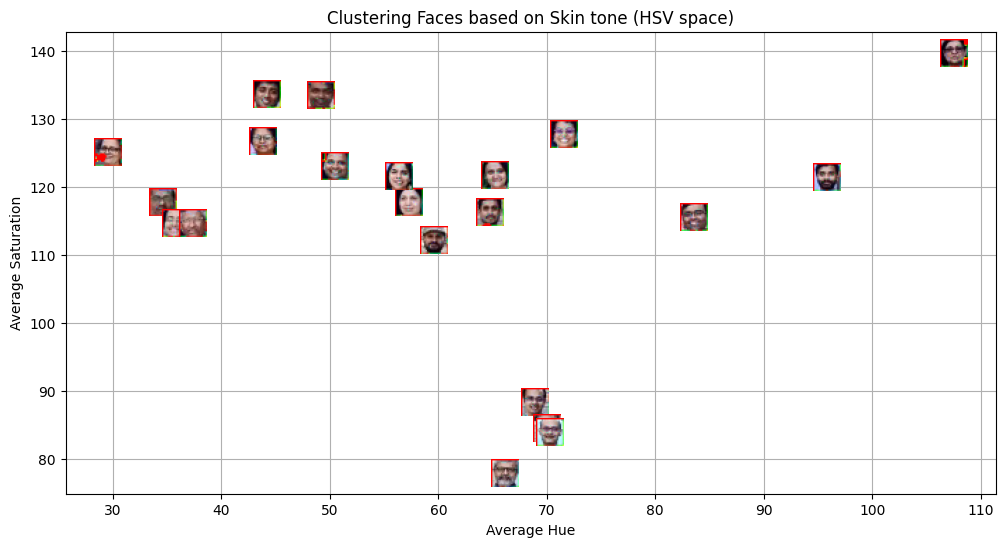

In [4]:

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Extract face region features (Hue and Saturation)
img_hsv = cv2.cvtColor(plaksha_faculty,cv2.COLOR_BGR2HSV) ## call the img and convert it from BGR to HSV and store in img_hsv
hue_saturation = []
face_images = []  # To store detected face images

for (x, y, w, h) in faces_rect:
    face = img_hsv[y:y + h, x:x + w]
    hue = np.mean(face[:, :, 0])
    saturation = np.mean(face[:, :, 1])
    hue_saturation.append((hue, saturation))
    face_images.append(face)

hue_saturation = np.array(hue_saturation)

## Perform k-Means clustering on hue_saturation and store in kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(hue_saturation)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x,y,w,h ) in enumerate(faces_rect):
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1])
    

plt.xlabel("Average Hue")
plt.ylabel("Average Saturation")
plt.title("Clustering Faces based on Skin tone (HSV space)")
plt.grid(True)
plt.show()

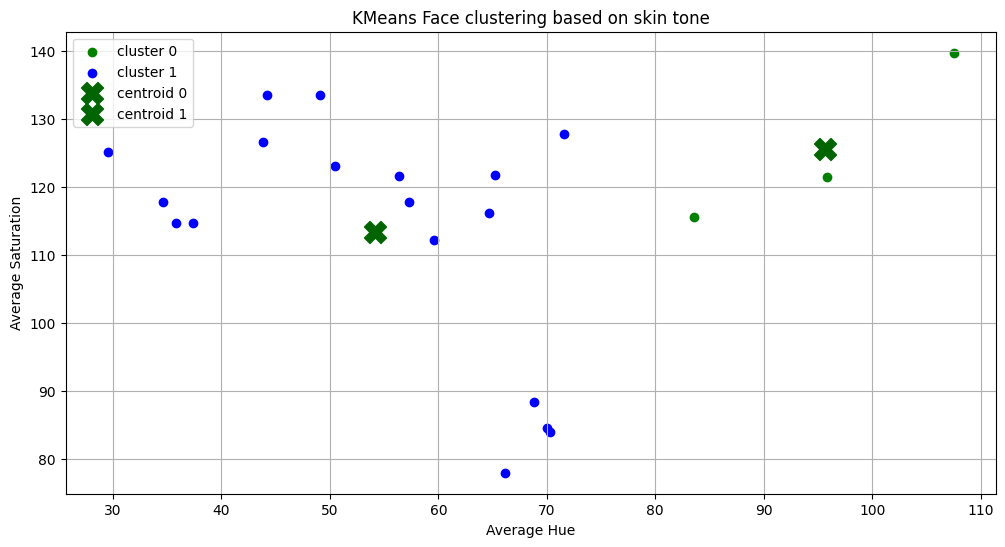

In [7]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))


cluster_0_points = np.array(cluster_0_points)
# Plot points for cluster 0 in green
plt.scatter(cluster_0_points[:,0], cluster_0_points[:,1], c="green",label="cluster 0")


cluster_1_points = np.array(cluster_1_points)
# Plot points for cluster 1 in blue
plt.scatter(cluster_1_points[:,0], cluster_1_points[:,1], c="blue", label="cluster 1")

# Calculate and plot centroids
centroid_0 = np.mean(cluster_0_points, axis=0)
centroid_1 = np.mean(cluster_1_points, axis=0)

# Plot both the centroid for cluster 0 and cluster 1 
plt.scatter(centroid_0[0], centroid_0[1], c="darkgreen", marker="X", s=250, label="centroid 0")
plt.scatter(centroid_1[0], centroid_1[1], c="darkgreen", marker="X", s=250, label="centroid 1")


plt.xlabel("Average Hue")
plt.ylabel("Average Saturation")
plt.title("KMeans Face clustering based on skin tone")
plt.legend()
plt.grid(True)
plt.show()



In [19]:
## Read the class of the template image 'Dr_Shashi_Tharoor.jpg' using cv2 and store it in template_img
template_img = cv2.imread("Dr_Shashi_Tharoor.jpg")
# Detect face  in the template image after converting it to gray and store it in template_faces
img_grey= cv2.cvtColor(template_img, cv2.COLOR_RGB2GRAY)
template_faces = face_cascade.detectMultiScale(img_grey,1.1,5)
# Draw rectangles around the detected faces
for (x, y, w, h) in template_faces:
    cv2.rectangle(template_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
cv2.imshow("Dr Shashi Tharoor (Template Image)",template_img)
cv2.waitKey(0)
cv2.destroyAllWindows()      

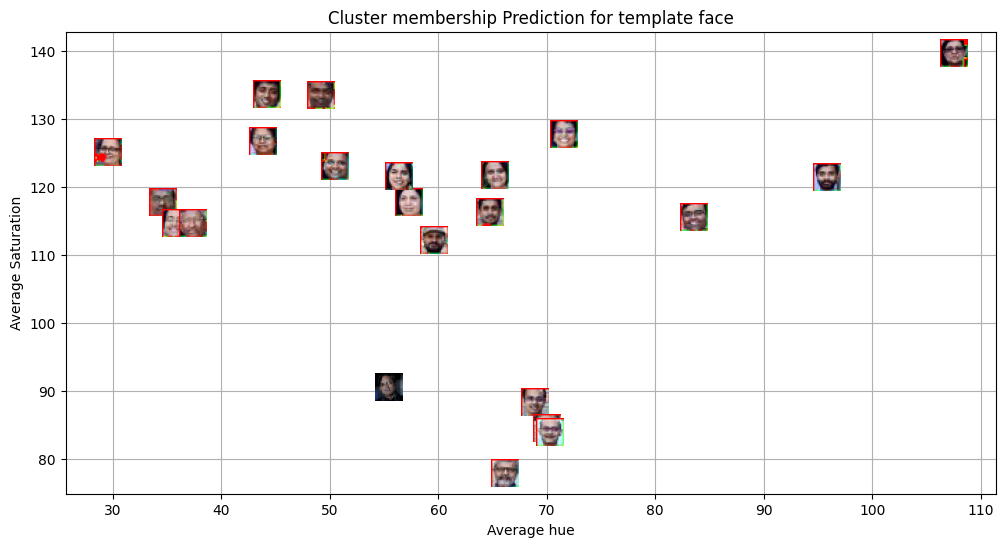

In [15]:
# Convert the template image to HSV color space and store it in template_hsv
template_hsv = cv2.cvtColor(template_img,cv2.COLOR_RGB2HSV)

# Extract hue and saturation features from the template image as we did it for detected faces.
template_hue = np.mean(template_hsv[:,:,0])
template_saturation = np.mean(template_hsv[:,:,1])

# Predict the cluster label for the template image and store it in template_label
template_label = kmeans.predict([[template_hue,template_saturation]])[0]

# Create a figure and axis for visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers (similar to previous code)
for i, (x, y, w, h) in enumerate(faces_rect):
    color = 'red' if kmeans.labels_[i] == 0 else 'blue'
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1], 'o', markersize=5, color=color)

# Plot the template image in the respective cluster
if template_label == 0:
    color = 'red'
else:
    color = 'blue'
im = OffsetImage(cv2.cvtColor(cv2.resize(template_img, (20, 20)), cv2.COLOR_BGR2RGB))
ab = AnnotationBbox(im, (template_hue, template_saturation), frameon=False, pad=0)
ax.add_artist(ab)

plt.xlabel("Average hue")##Put x label
plt.ylabel("Average Saturation")## Put y label
plt.title("Cluster membership Prediction for template face")## Put title
plt.grid(True)## Add grid
plt.show()## show plot

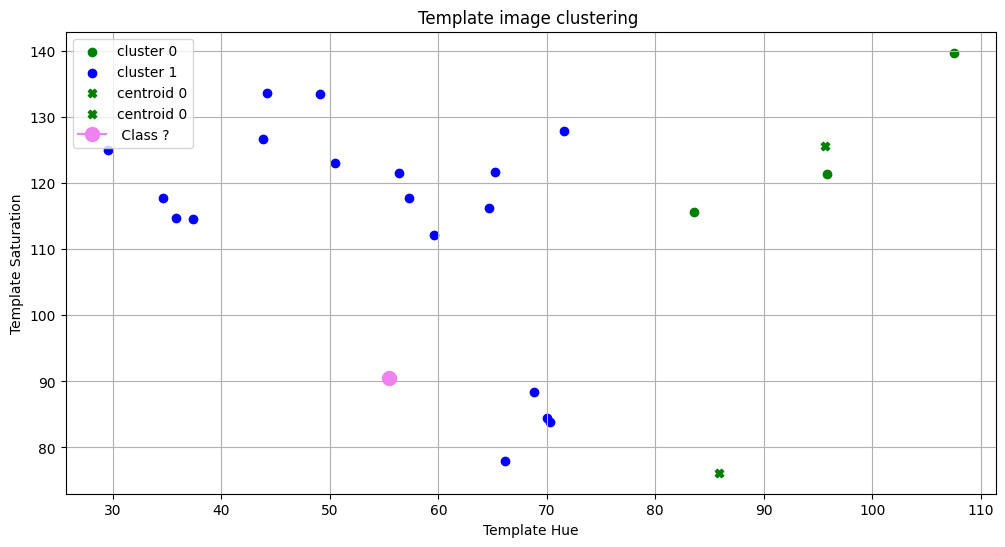

In [ ]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Plot points for cluster 0 in green
cluster_0_points = np.array(cluster_0_points)
plt.scatter(cluster_0_points[:,0],cluster_0_points[:,1],c="green",label="cluster 0")

# Plot points for cluster 1 in blue
cluster_1_points = np.array(cluster_1_points)
plt.scatter(cluster_1_points[:,0],cluster_1_points[:,1], c="blue", label="cluster 1" )

# Calculate and plot centroids for both the clusters
centroid_0 = np.mean(cluster_0_points, axis=0)
centroid_1 = np.mean(cluster_1_points, axis=1)
plt.scatter(centroid_0[0], centroid_0[1], c="green", marker="X",label="centroid 0") ## plot for centroid 0
plt.scatter(centroid_1[0],centroid_1[1], c="green", marker="X", label="centroid 0")  ## plot for centroid 1
plt.plot(template_hue, template_saturation, marker='o', c= 'violet',markersize= 10, label=' Class ' )

plt.xlabel("Template Hue")## Put x label
plt.ylabel("Template Saturation")## Put y label
plt.title("Template image clustering ") ## Put title
plt.legend() ## Add a legend
plt.grid(True)## Add grid
plt.show() ## show the plot
                                            ## End of the lab 5 ##

## Report:
## Answer the following questions within your report:


#### 1. What are the common distance metrics used in distance-based classification algorithms? 

##### Ans: Euclidean, Mahalanobis, Manhatten, Chebyshev, Minkowski, cosine, Hamming distance matrices. 

#### 2. What are some real-world applications of distance-based classification algorithms? 

##### Ans: Distance based classification algorithms 

#### 3. Explain various distance metrics are widely used in face recognition, reccomendation system, etc. 

##### Ans: 1. Eucleidian: Represents the shortest distance between two vectors.
##### 2. Mahalanobis: Represents the distance between a point P and a distribution D.
##### 3. Manhatten: Distance between two points measured along axes at right angles.
##### 4. Minkowski: A generalized distance metric which can be modified by substituting the value of ‘p’ to calculate the distance between two points.
##### If p = 1, Manhattan Distance, called L1 norm
##### If p = 2, Euclidean Distance, called L2 norm
##### If p = ∞, Chebychev Distance, called L∞ norm
##### 5. Cosine: Degree of angle between two vectors (called frequencies forwords in documents). It is used when the magnitude does not matter but rather their orientation matters.
##### 6. Chebyshev: Distance between two vectors is the greatest of their differences along any coordinate dimension
##### 7. Hamming: Hamming distance is the number of positions at which two equal-length sequences differ.
#### 4. What is the role of cross validation in model performance? 

##### Ans: Cross-validation evaluates a model on multiple train–test splits so performance reflects how well it generalizes to unseen data, reducing overfitting and giving a more reliable accuracy estimate.

#### 5. Explain variance and bias in terms of KNN? 

##### Ans: bias means the model missis the pattern or not predicts the correct value. varience means unstable prediction, the prediction are not precise.  Small K -low bias & high variance , Large K high bias, low variance